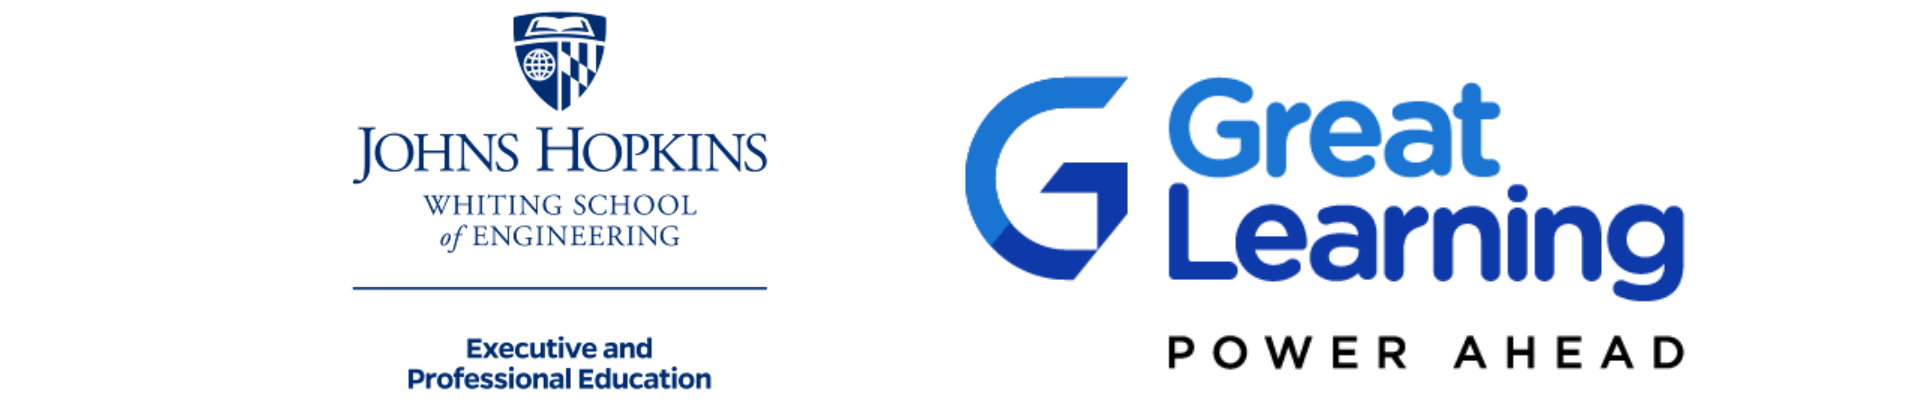

# 🤖 Reinforcement Learning : Autonomous Warehouse Navigation


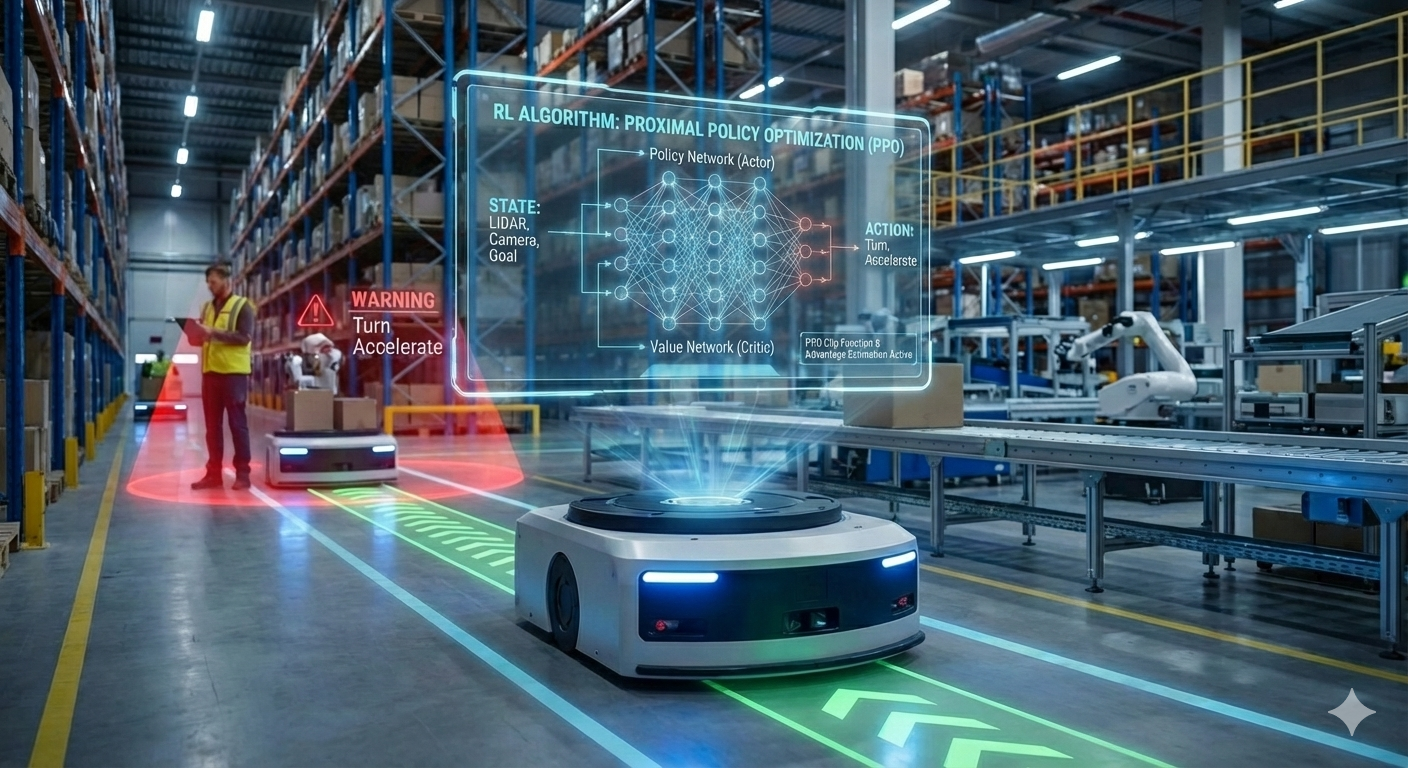

## 📋 Case Study Overview

**Business Problem:** GlobalLogistics Corp's autonomous mobile robots struggle with efficient warehouse navigation when layouts change dynamically.

**Challenge:** Create intelligent navigation agents that learn optimal pathfinding strategies without manual programming for every scenario.

**Solution:** Proximal Policy Optimization (PPO) - a state-of-the-art Reinforcement Learning algorithm.

---

## 🎯 Learning Objectives

By the end of this notebook, you will understand:

1. **RL Environment Design** - How to model real-world problems as RL environments
2. **Reward Shaping** - Critical techniques to guide agent learning
3. **PPO Algorithm** - Policy gradient method for stable training
4. **Before/After Visualization** - Demonstrating learning effectiveness
5. **Multi-Difficulty Evaluation** - Testing agent generalization

---

## 📊 Expected Results

- **Before Training:** Random wandering
- **After Training:** Goal-directed navigation
- **Training Time:** ~5-10 minutes on GPU


---

# 🔧 SECTION 1: Environment Setup

Installing required libraries for RL training and visualization.


In [1]:
# # ============================================================================
# # INSTALLATION: Core RL and Visualization Libraries
# # ============================================================================
# #
# # gymnasium: Standard RL environment interface (successor to OpenAI Gym)
# # stable-baselines3: State-of-the-art RL algorithms including PPO
# # pillow: Image processing for grid visualization
# # imageio: GIF creation for before/after comparisons
# #
# # Installation time: ~30-60 seconds
# # ============================================================================

# !pip install gymnasium==1.2.3 \
# stable-baselines3[extra]==2.7.1 \
# pillow==11.3.0 \
# imageio==2.37.2

# print("✅ Installation complete!")
# print("📦 Packages installed: gymnasium, stable-baselines3, pillow, imageio")

In [2]:
# ============================================================================
# IMPORTS: Required Libraries
# ============================================================================

# Core Python libraries
import numpy as np                          # Numerical computing
import time                                 # Performance timing
import os                                   # File operations
from collections import deque               # Efficient queue for BFS

# Gymnasium: RL environment framework
import gymnasium as gym
from gymnasium import spaces

# Stable-Baselines3: RL algorithms
from stable_baselines3 import PPO                        # PPO algorithm
from stable_baselines3.common.env_util import make_vec_env  # Parallel envs
from stable_baselines3.common.callbacks import BaseCallback  # Training callbacks

# Visualization libraries
import imageio                              # GIF generation
from PIL import Image, ImageDraw            # Image creation
from IPython.display import Image as IPImage, display  # Notebook display

print("✅ All imports successful!")
print("🚀 Ready to build the GridWorld environment")

✅ All imports successful!
🚀 Ready to build the GridWorld environment


---

# 🏗️ SECTION 2: Environment Design - The Warehouse Simulation

## Problem Modeling

We model the warehouse as a **GridWorld** where:

- 🟦 **S (Start)** = Robot's initial position (varies each episode)
- 🟩 **G (Goal)** = Package pickup/delivery location (varies each episode)
- ⬛ **X (Obstacle)** = Storage racks, temporary blockages
- ⬜ **. (Empty)** = Navigable floor space
- 🔴 **A (Agent)** = Robot's current position

## Key RL Components

### 1. **State Space (Observation)**
```
[agent_x_normalized, agent_y_normalized, goal_x_normalized, goal_y_normalized]
```
- Normalized to [0, 1] range for stable neural network training
- Tells agent: "Where am I? Where do I need to go?"

### 2. **Action Space**
```
0 = UP    (↑)
1 = RIGHT (→)
2 = DOWN  (↓)
3 = LEFT  (←)
```
**Note :** To travel in diagonals, the agent would need to perform 2 steps

Eg. Agent wants to go in Top-Right corner from it's current position
- Path 1 -> UP (↑) + Right (→)
- Path 2 -> Right (→) + UP (↑)


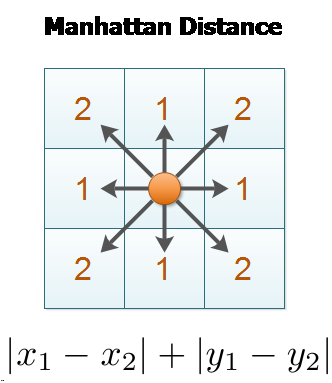


### 3. **Reward Function** (Critical for Learning!)
```
Goal Reached:           +50.0  (Mission accomplished!)
Moving Closer:          +1.0   (Good progress)
Moving Away:            -0.5   (Wrong direction)
Wall Collision:         -5.0   (Invalid move penalty)
New Cell Visited:       +0.3   (Exploration bonus)
Timeout (>100 steps):   -10.0  (Efficiency penalty)
```

### 4. **Episode Termination**
- ✅ Success: Agent reaches goal
- ❌ Failure: 100 steps exceeded (timeout)


<br>

**Note:** Episode is one complete attempt by the agent to navigate from the start position (S) to the goal position (G), ending when either the goal is reached or a timeout

---

## Design Principles

✅ **Random Grid Generation** - Forces agent to learn general navigation, not memorize specific layouts  
✅ **Path Validation** - BFS ensures every generated grid has a valid solution  
✅ **Distance-Based Rewards** - Creates learning gradient toward goal  
✅ **Obstacle Penalty** - Discourages wall collisions  
✅ **Exploration Incentive** - Rewards discovering new areas  

In [2]:
# ============================================================================
# GRIDWORLD ENVIRONMENT: Custom Gymnasium Environment
# ============================================================================
#
# This class defines the warehouse navigation environment with:
# - Randomized grid layouts (varying start/goal positions)
# - Configurable obstacle density
# - Shaped reward function for effective learning
# - Path validation to ensure solvability
#
# ============================================================================

class GridWorldEnv(gym.Env):
    """
    Custom GridWorld environment for warehouse navigation training.

    Features:
    - Auto-generates random grid layouts each episode
    - Validates path existence between start and goal
    - Provides normalized observations for stable learning
    - Implements reward shaping for efficient training
    """

    def __init__(self, grid=None, grid_size=5, auto_generate=True, obstacle_density=0.2):
        """
        Initialize the GridWorld environment.

        Args:
            grid: Optional pre-defined grid layout (None for random)
            grid_size: Size of square grid (default: 5x5)
            auto_generate: Whether to generate new grids each episode
            obstacle_density: Fraction of cells that are obstacles (0.0-1.0)
        """
        super().__init__()
        self.grid_size = grid_size
        self.auto_generate = auto_generate
        self.obstacle_density = obstacle_density

        # Generate initial grid if not provided
        if grid is None and auto_generate:
            self.grid = self._generate_random_grid()
        else:
            self.grid = grid if grid is not None else np.full((grid_size, grid_size), '.', dtype=str)

        # Define action space: 4 discrete actions (up, right, down, left)
        self.action_space = spaces.Discrete(4)

        # Define observation space: [agent_x, agent_y, goal_x, goal_y] normalized to [0, 1]
        # WHY NORMALIZED? Neural networks train better with inputs in similar ranges
        self.observation_space = spaces.Box(
            low=0.0,
            high=1.0,
            shape=(4,),
            dtype=np.float32
        )

        # Extract start and goal positions from grid
        self.start = tuple(np.argwhere(self.grid == 'S')[0]) if 'S' in self.grid else (0, 0)
        self.goal = tuple(np.argwhere(self.grid == 'G')[0]) if 'G' in self.grid else (grid_size-1, grid_size-1)
        self.state = self.start

        # Track initial distance for reward shaping
        self.initial_distance = self._manhattan_distance(self.start, self.goal)

    def _generate_random_grid(self):
        """
        Generate a random grid with varied start/goal positions and obstacles.

        Key Feature: Validates that a path exists using BFS before returning.
        This prevents impossible-to-solve scenarios.

        Returns:
            numpy.ndarray: Valid grid layout with start, goal, and obstacles
        """
        max_attempts = 100  # Prevent infinite loops

        for attempt in range(max_attempts):
            # Create empty grid
            grid = np.full((self.grid_size, self.grid_size), '.', dtype=str)

            # Randomize start and goal positions (not always in corners!)
            available_positions = [(r, c) for r in range(self.grid_size)
                                   for c in range(self.grid_size)]
            np.random.shuffle(available_positions)

            start_pos = available_positions[0]
            goal_pos = available_positions[1]

            # Ensure start and goal are reasonably far apart
            # (Avoids trivial problems where goal is next to start)
            if self._manhattan_distance(start_pos, goal_pos) < self.grid_size // 2:
                continue

            # Place start and goal
            grid[start_pos] = 'S'
            grid[goal_pos] = 'G'

            # Add obstacles (avoiding start and goal)
            num_obstacles = int((self.grid_size * self.grid_size - 2) * self.obstacle_density)
            obstacle_candidates = [pos for pos in available_positions[2:]]

            if len(obstacle_candidates) >= num_obstacles:
                for i in range(num_obstacles):
                    r, c = obstacle_candidates[i]
                    grid[r, c] = 'X'

            # CRITICAL: Verify path exists using BFS
            if self._has_path_bfs(grid, start_pos, goal_pos):
                return grid

        # Fallback: simple grid with guaranteed path
        grid = np.full((self.grid_size, self.grid_size), '.', dtype=str)
        start_pos = (0, 0)
        goal_pos = (self.grid_size-1, self.grid_size-1)
        grid[start_pos] = 'S'
        grid[goal_pos] = 'G'
        return grid

    def _has_path_bfs(self, grid, start, goal):
        """
        Breadth-First Search to verify a valid path exists.

        Why BFS? Guarantees finding shortest path if one exists.

        Args:
            grid: Grid layout to check
            start: Starting position (row, col)
            goal: Goal position (row, col)

        Returns:
            bool: True if path exists, False otherwise
        """
        queue = deque([start])
        visited = {start}
        directions = [(-1,0), (0,1), (1,0), (0,-1)]  # up, right, down, left

        while queue:
            r, c = queue.popleft()
            if (r, c) == goal:
                return True

            for dr, dc in directions:
                nr, nc = r + dr, c + dc
                if (0 <= nr < self.grid_size and 0 <= nc < self.grid_size and
                    (nr, nc) not in visited and grid[nr, nc] != 'X'):
                    visited.add((nr, nc))
                    queue.append((nr, nc))

        return False

    def _manhattan_distance(self, pos1, pos2):
        """
        Calculate Manhattan distance (L1 distance) between two positions.

        Manhattan distance = |x1 - x2| + |y1 - y2|

        Why Manhattan? In grid worlds, you can only move
        horizontally/vertically, so this is the true distance metric.

        Args:
            pos1: First position (row, col)
            pos2: Second position (row, col)

        Returns:
            int: Manhattan distance
        """
        return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])

    def reset(self, *, seed=None, options=None):
        """
        Reset environment to start a new episode.

        If auto_generate=True, creates a new random grid layout.
        This forces the agent to learn general navigation strategies.

        Returns:
            observation: Initial state [agent_x, agent_y, goal_x, goal_y]
            info: Empty dictionary (required by Gymnasium API)
        """
        super().reset(seed=seed)

        # Generate new grid if auto-generation enabled
        if self.auto_generate:
            self.grid = self._generate_random_grid()
            self.start = tuple(np.argwhere(self.grid == 'S')[0])
            self.goal = tuple(np.argwhere(self.grid == 'G')[0])

        # Reset episode state
        self.state = self.start
        self.visited = {self.start}  # Track visited cells for exploration bonus
        self.steps = 0
        self.initial_distance = self._manhattan_distance(self.start, self.goal)
        self.prev_distance = self.initial_distance

        return self._get_observation(), {}

    def _get_observation(self):
        """
        Create normalized observation vector.

        Normalization Formula: position / (grid_size - 1)
        Maps grid coordinates to [0, 1] range.

        Example for 5x5 grid:
        - Position (0, 0) → (0.0, 0.0)
        - Position (2, 3) → (0.5, 0.75)
        - Position (4, 4) → (1.0, 1.0)

        Returns:
            numpy.ndarray: [agent_x_norm, agent_y_norm, goal_x_norm, goal_y_norm]
        """
        obs = np.array([
            self.state[0] / (self.grid_size - 1),
            self.state[1] / (self.grid_size - 1),
            self.goal[0] / (self.grid_size - 1),
            self.goal[1] / (self.grid_size - 1)
        ], dtype=np.float32)
        return obs

    def step(self, action):
        """
        Execute one action in the environment.

        This is the HEART of the RL environment - where rewards are computed
        and the agent learns from consequences of its actions.

        Args:
            action: Integer 0-3 (up, right, down, left)

        Returns:
            observation: New state after action
            reward: Reward for this transition
            terminated: Whether episode ended (goal reached or timeout)
            truncated: Whether episode was cut off (always False here)
            info: Additional information dictionary
        """
        r, c = self.state
        moves = [(-1,0), (0,1), (1,0), (0,-1)]  # up, right, down, left
        dr, dc = moves[action]
        nr, nc = r + dr, c + dc

        self.steps += 1
        current_distance = self._manhattan_distance(self.state, self.goal)

        # Check if move is valid (within bounds and not hitting obstacle)
        if nr < 0 or nr >= self.grid_size or nc < 0 or nc >= self.grid_size or self.grid[nr,nc] == 'X':
            # INVALID MOVE: Hit wall or obstacle
            # Strong penalty to discourage this behavior
            reward = -5.0
            # Agent stays in place (doesn't move through walls)
        else:
            # VALID MOVE: Update position
            self.state = (nr, nc)
            new_distance = self._manhattan_distance(self.state, self.goal)

            # REWARD SHAPING: Guide agent toward goal
            if new_distance < self.prev_distance:
                # Moving closer to goal - POSITIVE reinforcement
                reward = 1.0
            elif new_distance > self.prev_distance:
                # Moving away from goal - Small negative
                reward = -0.5
            else:
                # Same distance - Neutral (slight negative to encourage progress)
                reward = -0.1

            self.prev_distance = new_distance

            # EXPLORATION BONUS: Encourage visiting new cells
            # Helps agent discover optimal paths
            if self.state not in self.visited:
                self.visited.add(self.state)
                reward += 0.3

        # Check termination conditions

        # SUCCESS: Reached goal!
        if self.state == self.goal:
            reward = 50.0  # Large positive reward for mission accomplishment
            return self._get_observation(), reward, True, False, {'success': True, 'steps': self.steps}

        # TIMEOUT: Took too long (inefficient navigation)
        if self.steps >= 100:
            reward = -10.0  # Penalty for taking too many steps
            return self._get_observation(), reward, True, False, {'success': False, 'steps': self.steps}

        # Episode continues
        return self._get_observation(), reward, False, False, {}

    def render(self):
        """
        Create text representation of current grid state.
        Useful for debugging and visualizing agent position.

        Returns:
            str: Text-based grid visualization
        """
        grid_vis = self.grid.copy()
        r, c = self.state
        grid_vis[r,c] = 'A'  # Mark agent position
        return "\n".join([" ".join(row) for row in grid_vis])

print("✅ GridWorld Environment class defined!")
print("🎮 Environment features:")
print("   - Random grid generation")
print("   - Path validation (BFS)")
print("   - Shaped reward function")
print("   - Normalized observations")

✅ GridWorld Environment class defined!
🎮 Environment features:
   - Random grid generation
   - Path validation (BFS)
   - Shaped reward function
   - Normalized observations


---

# 🎨 SECTION 3: Visualization Functions

Creating visual representations to demonstrate learning progress.


In [3]:
# ============================================================================
# VISUALIZATION: Convert grid states to images and GIFs
# ============================================================================
#
# These functions create visual representations of agent navigation:
# - grid_to_image(): Creates single frame image
# - make_gif(): Creates animated GIF of full episode
#
# Purpose: Demonstrate learning effectiveness through before/after comparison
# ============================================================================

def grid_to_image(grid, agent_pos, grid_size=5):
    """
    Convert grid state to PIL Image for visualization.

    Color Scheme:
    - Dark Blue (#3498DB): Start position
    - Green (#2ECC71): Goal position
    - Dark Gray (#2C3E50): Obstacles
    - Light Gray (#ECF0F1): Empty space
    - Red (#E74C3C): Agent (robot)

    Args:
        grid: Grid layout (numpy array)
        agent_pos: Current agent position (row, col)
        grid_size: Size of grid

    Returns:
        PIL.Image: Rendered grid image
    """
    cell_size = 80  # Pixels per cell
    img_size = cell_size * grid_size
    img = Image.new('RGB', (img_size, img_size), 'white')
    draw = ImageDraw.Draw(img)

    # Draw grid cells
    for r in range(grid_size):
        for c in range(grid_size):
            x = c * cell_size
            y = r * cell_size
            val = grid[r, c]

            # Determine cell color based on type
            if val == 'X':
                color = '#2C3E50'  # Obstacle
            elif val == 'S':
                color = '#3498DB'  # Start
            elif val == 'G':
                color = '#2ECC71'  # Goal
            else:
                color = '#ECF0F1'  # Empty

            draw.rectangle([x, y, x+cell_size, y+cell_size],
                           outline='#34495E', width=2, fill=color)

    # Draw agent as red circle
    if agent_pos:
        ar, ac = agent_pos
        margin = 15  # Circle margin from cell edges
        draw.ellipse(
            [ac*cell_size+margin, ar*cell_size+margin,
             (ac+1)*cell_size-margin, (ar+1)*cell_size-margin],
            fill='#E74C3C'  # Agent
        )

    return img

def make_gif(env, policy, filename, random=False, max_steps=50):
    """
    Generate animated GIF of agent navigation through grid.

    Args:
        env: GridWorld environment instance
        policy: Trained PPO model (or None for random policy)
        filename: Output GIF filename
        random: If True, use random actions instead of policy
        max_steps: Maximum steps to record

    Returns:
        done: Whether goal was reached
        steps: Number of steps taken
    """
    frames = []
    obs, _ = env.reset()
    pos = tuple(env.state)

    # Add initial frame
    frames.append(grid_to_image(env.grid, pos, env.grid_size))

    # Run episode
    for step in range(max_steps):
        if random:
            action = env.action_space.sample()  # Random action
        else:
            action, _ = policy.predict(obs, deterministic=True)  # Policy action

        obs, reward, done, _, info = env.step(action)
        pos = tuple(env.state)
        frames.append(grid_to_image(env.grid, pos, env.grid_size))

        if done:
            # Add extra frames at end to pause on final state
            for _ in range(5):
                frames.append(grid_to_image(env.grid, pos, env.grid_size))
            break

    # Save as GIF
    imageio.mimsave(filename, frames, duration=0.3)  # 300ms per frame
    return done, info.get('steps', max_steps)

print("✅ Visualization functions defined!")
print("📹 Functions: grid_to_image(), make_gif()")

✅ Visualization functions defined!
📹 Functions: grid_to_image(), make_gif()


---

# 📊 SECTION 4: BEFORE TRAINING - Establishing Dual Baselines

## Demonstrating Two Types of Untrained Behavior

Before training, we need to understand **two distinct failure modes** that prove learning is necessary.

 This dual-baseline approach shows that neither random chance nor untrained neural networks can solve navigation.

---
### **Baseline 1: Pure Random Actions**
**The "No Intelligence" Control**
- Completely random action selection (25% probability each direction)
- No neural network, no decision logic whatsoever
- Like a robot randomly pressing buttons without sensors
- Expected: ~5-8% success rate (pure luck only)
- Theoretical maximum: Limited by obstacle density constraints
---
### **Baseline 2: Untrained Neural Network**  
**The "Random Weights" Failure**
- Uses PPO's MLP architecture but with random initialization
- Neural network exists but has **never seen training data**
- Actions are biased by random weight values, not intelligent
- Expected: ~4-12% success (slightly better/worse than pure random)
- Proves architecture alone cannot solve the task

---
**What to Observe:**
- Random wandering and wall collisions in both cases
- No systematic progress toward goals  
- Frequent timeout failures (100 steps exceeded)
- Visual GIFs show chaotic, uncoordinated movement

Let's establish these baselines before training demonstrates the transformation.


  BEFORE TRAINING - Baseline Performance


# BASELINE 1: Pure Random Actions (No Intelligence)

🎲 Test 1: PURE RANDOM ACTIONS
   - No model, no neural network
   - Like a robot with no programming
   - 25% chance for each action (UP, RIGHT, DOWN, LEFT)

   Result: ✅ Success in 14 steps
Pure Random Actions:


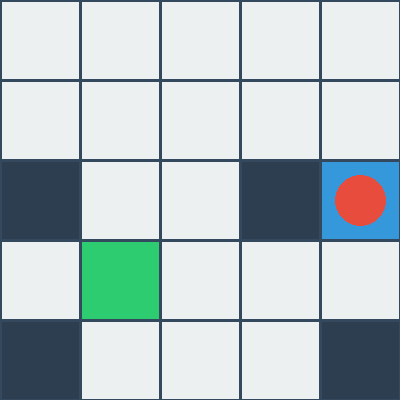


# BASELINE 2: Untrained Neural Network

🧠 Test 2: UNTRAINED NEURAL NETWORK (random weights)
   - Uses neural network with random initialization
   - Actions are biased by random weights



/home/z187900/courses/Agentic_AI_Johns_Hopkins_University/Agentic_AI_Johns_Hopkins_University/lib/python3.12/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


   Result: ❌ Failed in 50 steps

Untrained Model:


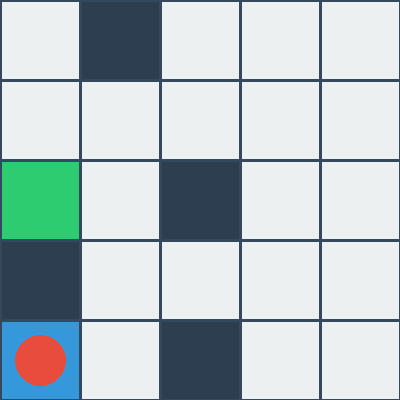


💡 Notice: Both perform poorly - neither has learned navigation strategies!
   After training, we'll see dramatic improvement...


In [4]:
# ============================================================================
# BEFORE TRAINING: Two Baseline Comparisons
# ============================================================================

print("="*70)
print("  BEFORE TRAINING - Baseline Performance")
print("="*70)
print("\n")
print("="*70)
print("# BASELINE 1: Pure Random Actions (No Intelligence)")
print("="*70)
print("\n🎲 Test 1: PURE RANDOM ACTIONS")
print("   - No model, no neural network")
print("   - Like a robot with no programming")
print("   - 25% chance for each action (UP, RIGHT, DOWN, LEFT)\n")


test_env_random = GridWorldEnv(grid_size=5, auto_generate=True, obstacle_density=0.2)
success_random, steps_random = make_gif(test_env_random, None, 'baseline_random.gif', random=True)

print(f"   Result: {'✅ Success' if success_random else '❌ Failed'} in {steps_random} steps")
print("Pure Random Actions:")
display(IPImage(filename='baseline_random.gif'))



print()
print("="*70)
print("# BASELINE 2: Untrained Neural Network")
print("="*70)
print("\n🧠 Test 2: UNTRAINED NEURAL NETWORK (random weights)")
print("   - Uses neural network with random initialization")
print("   - Actions are biased by random weights\n")

test_env_untrained = GridWorldEnv(grid_size=5, auto_generate=True, obstacle_density=0.2)

# Random initialization, no training
untrained_model = PPO("MlpPolicy", test_env_untrained)
success_untrained, steps_untrained = make_gif(test_env_untrained, untrained_model, 'baseline_untrained.gif', random=False)

print(f"   Result: {'✅ Success' if success_untrained else '❌ Failed'} in {steps_untrained} steps")
print("\nUntrained Model:")
display(IPImage(filename='baseline_untrained.gif'))

print()
print("="*70)
print("💡 Notice: Both perform poorly - neither has learned navigation strategies!")
print("   After training, we'll see dramatic improvement...")
print("="*70)

---

# 🚀 SECTION 5: PPO TRAINING - Teaching the Agent to Navigate

## Proximal Policy Optimization (PPO) Algorithm

### Why PPO?

✅ **Stable Learning** - Clipped objective prevents destructive policy updates  
✅ **Sample Efficient** - Reuses collected data multiple times  
✅ **Industry Standard** - Used by OpenAI, DeepMind for robotics/games  
✅ **Easy to Tune** - Robust hyperparameters work across many problems  

### How PPO Works (Simplified)

1. **Collect Experience** - Agent interacts with environment, gathering (state, action, reward) tuples
2. **Compute Advantages** - Which actions were better than expected?
3. **Update Policy** - Adjust neural network to favor good actions (but not too drastically)
4. **Repeat** - Continue until performance plateaus

### Key Hyperparameters

| Parameter | Value | Explanation |
|-----------|-------|-------------|
| **Learning Rate** | 3e-4 | How fast to update network weights |
| **Batch Size** | 64 | Samples per gradient update |
| **Training Epochs** | 10 | Times to reuse each batch of data |
| **Gamma (γ)** | 0.99 | Discount factor (how much to value future rewards) |
| **GAE Lambda (λ)** | 0.95 | Advantage estimation smoothing |
| **Clip Range** | 0.2 | Max policy change per update (stability) |
| **Entropy Coefficient** | 0.01 | Exploration bonus |

### Training Strategy

🔄 **Parallel Environments** (8 instances)  
- Faster data collection
- More diverse experiences
- Better generalization

📈 **Total Timesteps**: 200,000  
- ~5-10 minutes on GPU

---


In [5]:
# ============================================================================
# TRAINING CALLBACK: Monitor Progress During Training
# ============================================================================
#
# This callback prints training statistics every N steps
# Helps us understand if learning is progressing
#
# ============================================================================

class ProgressCallback(BaseCallback):
    """
    Custom callback to display training progress.

    Tracks:
    - Timesteps completed
    - Episodes finished
    - Average rewards
    """
    def __init__(self, check_freq=10000, verbose=1):
        """
        Args:
            check_freq: Print progress every N timesteps
            verbose: Verbosity level
        """
        super().__init__(verbose)
        self.check_freq = check_freq
        self.best_mean_reward = -np.inf

    def _on_step(self) -> bool:
        """
        Called after each environment step.
        Prints progress updates at specified frequency.
        """
        if self.n_calls % self.check_freq == 0:
            print(f"   ⏱️  Timesteps: {self.num_timesteps:,} / 200,000")
        return True  # Continue training

print("✅ Training callback defined!")

✅ Training callback defined!


In [6]:
# ============================================================================
# TRAINING FUNCTION: PPO Training Pipeline
# ============================================================================
#
# This function encapsulates the entire training process:
# 1. Create vectorized (parallel) environments
# 2. Initialize PPO model with tuned hyperparameters
# 3. Train for specified timesteps
# 4. Save trained model
#
# ============================================================================

def train_ppo_agent(grid_size=5, total_timesteps=200000, n_envs=8, model_path="gridworld_ppo"):
    """
    Train PPO agent for warehouse navigation.

    Args:
        grid_size: Size of grid (5 = 5x5 grid)
        total_timesteps: Total training steps
        n_envs: Number of parallel environments
        model_path: Where to save trained model

    Returns:
        model: Trained PPO agent
    """
    print("=" * 70)
    print("  PPO TRAINING - Teaching Agent to Navigate")
    print("=" * 70)

    # Start with moderate obstacle density (not too hard, not too easy)
    obstacle_density = 0.2  # 20% of cells are obstacles

    print(f"\n🎯 Training Configuration:")
    print(f"   Grid Size: {grid_size}x{grid_size}")
    print(f"   Obstacle Density: {obstacle_density*100:.0f}%")
    print(f"   Parallel Environments: {n_envs}")
    print(f"   Total Timesteps: {total_timesteps:,}")
    print(f"   Estimated Time: 5-10 minutes (GPU) / 20-30 minutes (CPU)")

    # Create vectorized (parallel) environments
    # Why parallel? 8x faster data collection!
    print(f"\n🏗️  Creating {n_envs} parallel environments...")
    vec_env = make_vec_env(
        lambda: GridWorldEnv(
            grid_size=grid_size,
            auto_generate=True,  # Generate new grids each episode
            obstacle_density=obstacle_density
        ),
        n_envs=n_envs
    )
    print("   ✅ Environments created!")

    # Initialize PPO model with tuned hyperparameters
    print(f"\n🤖 Initializing PPO model with neural network policy...")
    model = PPO(
        "MlpPolicy",              # Multi-Layer Perceptron (neural network)
        vec_env,
        learning_rate=3e-4,       # Standard learning rate for PPO
        n_steps=2048,             # Steps per env before policy update
        batch_size=64,            # Minibatch size for gradient descent
        n_epochs=10,              # Times to reuse each data batch
        gamma=0.99,               # Discount factor (value future rewards)
        gae_lambda=0.95,          # Generalized Advantage Estimation
        clip_range=0.2,           # PPO clipping (prevents big policy changes)
        ent_coef=0.01,            # Entropy bonus (encourages exploration)
        vf_coef=0.5,              # Value function loss coefficient
        max_grad_norm=0.5,        # Gradient clipping (training stability)
        verbose=1                 # Print training info
    )
    print("   ✅ Model initialized!")
    print("   📊 Policy Network: 2 hidden layers (64 neurons each)")
    print("   🎲 Input: [agent_x, agent_y, goal_x, goal_y]")
    print("   🎯 Output: Action probabilities [up, right, down, left]")

    # Start training!
    print(f"\n🚀 Starting training for {total_timesteps:,} timesteps...")
    print("   (Progress updates every 10,000 steps)\n")

    callback = ProgressCallback(check_freq=10000)

    start_time = time.time()
    model.learn(
        total_timesteps=total_timesteps,
        callback=callback,
        progress_bar=True
    )
    training_time = time.time() - start_time

    # Close parallel environments
    vec_env.close()

    # Save trained model
    model.save(model_path)
    print(f"\n✅ Training complete in {training_time/60:.1f} minutes!")
    print(f"💾 Model saved to: {model_path}.zip")
    print(f"\n🎓 Agent has learned from ~{total_timesteps:,} environment interactions!")

    return model

print("✅ Training function defined!")
print("   Ready to train when you run the next cell...")

✅ Training function defined!
   Ready to train when you run the next cell...


In [7]:
# ============================================================================
# EXECUTE TRAINING
# ============================================================================
#
# This cell runs the actual training process.
# Expected duration: 5-10 minutes on GPU, 20-30 minutes on CPU
#
# Watch for:
# - Episode reward increasing (learning is happening!)
# - Episode length decreasing (agent finding shorter paths)
#
# ============================================================================

# Train the agent
trained_model = train_ppo_agent(
    grid_size=5,
    total_timesteps=200000,
    n_envs=8,
    model_path="gridworld_ppo_trained"
)

print("\n" + "="*70)
print("  🎉 TRAINING PHASE COMPLETE!")
print("="*70)
print("\n📈 Next: Evaluate the trained agent's performance...")

Output()

  PPO TRAINING - Teaching Agent to Navigate

🎯 Training Configuration:
   Grid Size: 5x5
   Obstacle Density: 20%
   Parallel Environments: 8
   Total Timesteps: 200,000
   Estimated Time: 5-10 minutes (GPU) / 20-30 minutes (CPU)

🏗️  Creating 8 parallel environments...
   ✅ Environments created!

🤖 Initializing PPO model with neural network policy...
Using cuda device
   ✅ Model initialized!
   📊 Policy Network: 2 hidden layers (64 neurons each)
   🎲 Input: [agent_x, agent_y, goal_x, goal_y]
   🎯 Output: Action probabilities [up, right, down, left]

🚀 Starting training for 200,000 timesteps...
   (Progress updates every 10,000 steps)



---------------------------------
| rollout/           |          |
|    ep_len_mean     | 54.2     |
|    ep_rew_mean     | -49.4    |
| time/              |          |
|    fps             | 3971     |
|    iterations      | 1        |
|    time_elapsed    | 4        |
|    total_timesteps | 16384    |
---------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 40.5        |
|    ep_rew_mean          | -9.2        |
| time/                   |             |
|    fps                  | 1402        |
|    iterations           | 2           |
|    time_elapsed         | 23          |
|    total_timesteps      | 32768       |
| train/                  |             |
|    approx_kl            | 0.013390748 |
|    clip_fraction        | 0.232       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.37       |
|    explained_variance   | 7.5e-05     |
|    learning_rate        | 0.0003      |
|    loss                 | 216         |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.019      |
|    value_loss           | 538         |
-----------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 29.6        |
|    ep_rew_mean          | 9.26        |
| time/                   |             |
|    fps                  | 1187        |
|    iterations           | 3           |
|    time_elapsed         | 41          |
|    total_timesteps      | 49152       |
| train/                  |             |
|    approx_kl            | 0.011970738 |
|    clip_fraction        | 0.203       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.35       |
|    explained_variance   | -0.000157   |
|    learning_rate        | 0.0003      |
|    loss                 | 454         |
|    n_updates            | 20          |
|    policy_gradient_loss | -0.0162     |
|    value_loss           | 700         |
-----------------------------------------


...

------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 14           |
|    ep_rew_mean          | 23.3         |
| time/                   |              |
|    fps                  | 948          |
|    iterations           | 10           |
|    time_elapsed         | 172          |
|    total_timesteps      | 163840       |
| train/                  |              |
|    approx_kl            | 0.0062922477 |
|    clip_fraction        | 0.0366       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.06        |
|    explained_variance   | 0.107        |
|    learning_rate        | 0.0003       |
|    loss                 | 667          |
|    n_updates            | 90           |
|    policy_gradient_loss | -0.0028      |
|    value_loss           | 1.39e+03     |
------------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 13.1        |
|    ep_rew_mean          | 19.9        |
| time/                   |             |
|    fps                  | 938         |
|    iterations           | 11          |
|    time_elapsed         | 192         |
|    total_timesteps      | 180224      |
| train/                  |             |
|    approx_kl            | 0.006837408 |
|    clip_fraction        | 0.0341      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.03       |
|    explained_variance   | 0.128       |
|    learning_rate        | 0.0003      |
|    loss                 | 599         |
|    n_updates            | 100         |
|    policy_gradient_loss | -0.00277    |
|    value_loss           | 1.41e+03    |
-----------------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 15.6         |
|    ep_rew_mean          | 13.2         |
| time/                   |              |
|    fps                  | 933          |
|    iterations           | 12           |
|    time_elapsed         | 210          |
|    total_timesteps      | 196608       |
| train/                  |              |
|    approx_kl            | 0.0060818954 |
|    clip_fraction        | 0.0284       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.02        |
|    explained_variance   | 0.123        |
|    learning_rate        | 0.0003       |
|    loss                 | 989          |
|    n_updates            | 110          |
|    policy_gradient_loss | -0.00257     |
|    value_loss           | 1.48e+03     |
------------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 16.1        |
|    ep_rew_mean          | 18.8        |
| time/                   |             |
|    fps                  | 926         |
|    iterations           | 13          |
|    time_elapsed         | 229         |
|    total_timesteps      | 212992      |
| train/                  |             |
|    approx_kl            | 0.004514102 |
|    clip_fraction        | 0.0152      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.04       |
|    explained_variance   | 0.136       |
|    learning_rate        | 0.0003      |
|    loss                 | 684         |
|    n_updates            | 120         |
|    policy_gradient_loss | -0.00112    |
|    value_loss           | 1.52e+03    |
-----------------------------------------



✅ Training complete in 4.1 minutes!
💾 Model saved to: gridworld_ppo_trained.zip

🎓 Agent has learned from ~200,000 environment interactions!

  🎉 TRAINING PHASE COMPLETE!

📈 Next: Evaluate the trained agent's performance...


---

# 📊 SECTION 6: AFTER TRAINING - Evaluating the Trained Agent

## Performance Evaluation

Now let's test our trained agent across different difficulty levels to see how well it learned!

### Evaluation Metrics

🎯 **Success Rate** - Percentage of episodes where goal was reached  
⏱️ **Average Steps** - How efficiently the agent navigates  
🏆 **Best Performance** - Fewest steps to goal  

### Difficulty Levels

We test on three obstacle densities:

1. **Easy (15% obstacles)** - Sparse obstacles, many path options
2. **Medium (25% obstacles)** - Training difficulty level
3. **Hard (35% obstacles)** - Dense obstacles, challenging navigation

This tests **generalization** - can the agent adapt to scenarios it hasn't seen?

---


In [8]:
# ============================================================================
# EVALUATION FUNCTION: Test Trained Agent Performance
# ============================================================================
#
# Runs multiple episodes to measure:
# - Success rate (goal reached vs failed)
# - Average steps (efficiency)
# - Best performance (optimal navigation)
#
# ============================================================================

def evaluate_agent(model, grid_size=5, num_episodes=50, obstacle_density=0.2, render_sample=True):
    """
    Evaluate trained agent across multiple episodes.

    Args:
        model: Trained PPO agent
        grid_size: Grid dimensions
        num_episodes: Number of test episodes
        obstacle_density: Difficulty level (0.0-1.0)
        render_sample: Whether to generate sample GIF

    Returns:
        success_rate: Fraction of successful episodes
    """
    print(f"\n{'='*70}")
    print(f"  EVALUATION - Testing on {num_episodes} Episodes")
    print(f"  Difficulty: {obstacle_density*100:.0f}% Obstacles")
    print(f"{'='*70}")

    success_count = 0
    total_steps = 0
    successful_steps = []

    # Run evaluation episodes
    print(f"\n🧪 Running {num_episodes} test episodes...")
    for episode in range(num_episodes):
        # Create fresh environment for each episode
        env = GridWorldEnv(
            grid_size=grid_size,
            auto_generate=True,
            obstacle_density=obstacle_density
        )

        obs, _ = env.reset()
        done = False
        steps = 0

        # Run episode using trained policy
        while not done and steps < 100:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, _, info = env.step(action)
            steps += 1

        # Track results
        if info.get('success', False):
            success_count += 1
            successful_steps.append(steps)

        total_steps += steps

        # Print progress
        if (episode + 1) % 10 == 0:
            current_success_rate = success_count / (episode + 1)
            print(f"   Episode {episode+1}/{num_episodes} - Success Rate: {current_success_rate*100:.1f}%")

    # Calculate statistics
    success_rate = success_count / num_episodes
    avg_steps_all = total_steps / num_episodes
    avg_steps_success = np.mean(successful_steps) if successful_steps else 0

    # Display results
    print(f"\n📊 EVALUATION RESULTS:")
    print(f"   {'─'*60}")
    print(f"   ✅ Success Rate: {success_count}/{num_episodes} ({success_rate*100:.1f}%)")
    print(f"   📏 Avg Steps (all): {avg_steps_all:.1f}")
    if successful_steps:
        print(f"   🎯 Avg Steps (successful): {avg_steps_success:.1f}")
        print(f"   🏆 Best (fewest steps): {min(successful_steps)}")
        print(f"   📉 Worst (most steps): {max(successful_steps)}")
    print(f"   {'─'*60}")

    # Generate sample successful episode GIF
    if render_sample and success_rate > 0:
        print(f"\n📹 Generating sample successful episode GIF...")
        for attempt in range(20):  # Try multiple times to get success
            env = GridWorldEnv(grid_size=grid_size, auto_generate=True, obstacle_density=obstacle_density)
            gif_name = f'after_training_density_{int(obstacle_density*100)}.gif'
            success, steps = make_gif(env, model, gif_name)
            if success:
                print(f"   ✅ Captured successful episode in {steps} steps")
                print(f"   📁 Saved as: {gif_name}")
                print(f"\n⬇️ Watch the trained agent navigate:")
                display(IPImage(filename=gif_name))
                break

    return success_rate

print("✅ Evaluation function defined!")

✅ Evaluation function defined!



  🟢 DIFFICULTY LEVEL: EASY

  EVALUATION - Testing on 50 Episodes
  Difficulty: 10% Obstacles

🧪 Running 50 test episodes...
   Episode 10/50 - Success Rate: 80.0%
   Episode 20/50 - Success Rate: 80.0%
   Episode 30/50 - Success Rate: 80.0%
   Episode 40/50 - Success Rate: 77.5%
   Episode 50/50 - Success Rate: 80.0%

📊 EVALUATION RESULTS:
   ────────────────────────────────────────────────────────────
   ✅ Success Rate: 40/50 (80.0%)
   📏 Avg Steps (all): 22.5
   🎯 Avg Steps (successful): 3.1
   🏆 Best (fewest steps): 2
   📉 Worst (most steps): 7
   ────────────────────────────────────────────────────────────

📹 Generating sample successful episode GIF...
   ✅ Captured successful episode in 7 steps
   📁 Saved as: after_training_density_10.gif

⬇️ Watch the trained agent navigate:


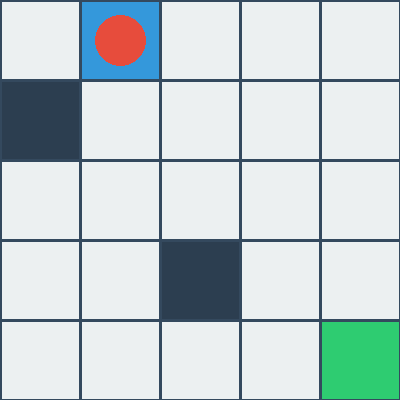

In [9]:
# ============================================================================
# EVALUATION: Easy Difficulty (15% obstacles)
# ============================================================================
#
# Testing agent on easier scenarios than training.
# Expected: High success rate (>70%)
#
# ============================================================================

print("\n" + "="*70)
print("  🟢 DIFFICULTY LEVEL: EASY")
print("="*70)

easy_success_rate = evaluate_agent(
    model=trained_model,
    grid_size=5,
    num_episodes=50,
    obstacle_density=0.1,  # 15% obstacles
    render_sample=True
)

##### **The Agent has been trained on a 5x5 Grid. <br> So now let's try to increase the `grid_size` and the `obstacle_density` to observe its performance.**


  🟡 DIFFICULTY LEVEL: MEDIUM

  EVALUATION - Testing on 50 Episodes
  Difficulty: 25% Obstacles

🧪 Running 50 test episodes...
   Episode 10/50 - Success Rate: 10.0%
   Episode 20/50 - Success Rate: 10.0%
   Episode 30/50 - Success Rate: 6.7%
   Episode 40/50 - Success Rate: 12.5%
   Episode 50/50 - Success Rate: 10.0%

📊 EVALUATION RESULTS:
   ────────────────────────────────────────────────────────────
   ✅ Success Rate: 5/50 (10.0%)
   📏 Avg Steps (all): 90.8
   🎯 Avg Steps (successful): 7.8
   🏆 Best (fewest steps): 6
   📉 Worst (most steps): 11
   ────────────────────────────────────────────────────────────

📹 Generating sample successful episode GIF...
   ✅ Captured successful episode in 8 steps
   📁 Saved as: after_training_density_25.gif

⬇️ Watch the trained agent navigate:


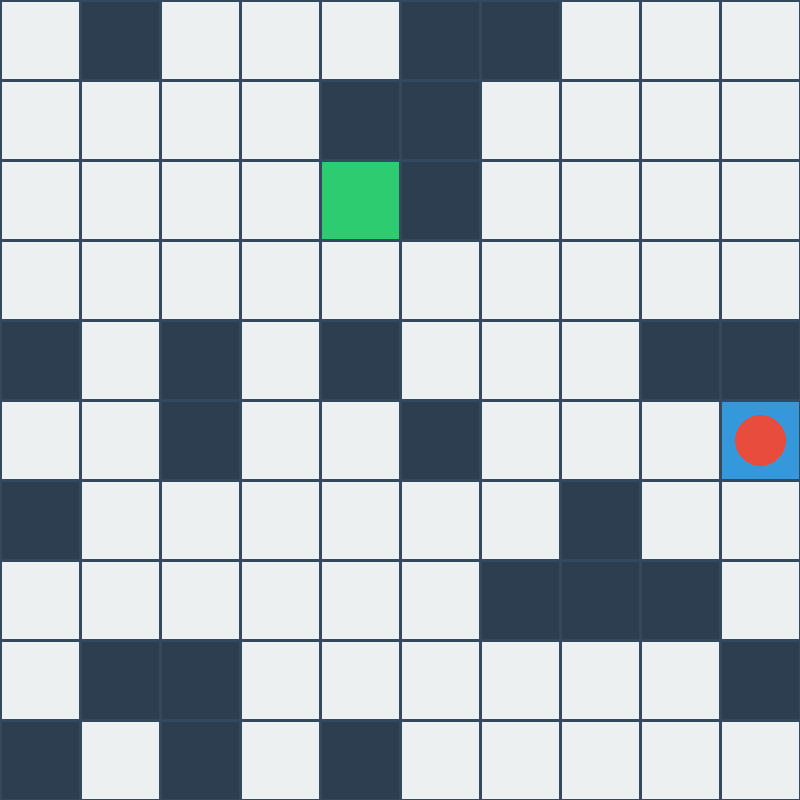

In [10]:
# ============================================================================
# EVALUATION: Medium Difficulty (25% obstacles)
# ============================================================================
#
# Testing on harder scenarios than training.
# Tests generalization capability.
# Expected: Moderate success rate (50-65%)
#
# ============================================================================

print("\n" + "="*70)
print("  🟡 DIFFICULTY LEVEL: MEDIUM")
print("="*70)

medium_success_rate = evaluate_agent(
    model=trained_model,
    grid_size=10,
    num_episodes=50,
    obstacle_density=0.25,  # 25% obstacles
    render_sample=True
)

##### **Out of 50 episodes, the agent successfully traversed the environment and reached the goal state in 5 episodes. <br>Hence, the success rate was 10%.**

##### **Now let's try to increase the `grid_size` and the `obstacle_density` even more to see how our agent performs in a bigger environment with more blockages**

In [11]:
# ============================================================================
# EVALUATION: Hard Difficulty (35% obstacles)
# ============================================================================
#
# Stress test on very challenging scenarios.
# Many paths blocked, requires clever navigation.
# Expected: Lower success rate (30-50%)
#
# ============================================================================

print("\n" + "="*70)
print("  🔴 DIFFICULTY LEVEL: HARD")
print("="*70)

hard_success_rate = evaluate_agent(
    model=trained_model,
    grid_size=15,
    num_episodes=50,
    obstacle_density=0.35,  # 35% obstacles
    render_sample=True
)


  🔴 DIFFICULTY LEVEL: HARD

  EVALUATION - Testing on 50 Episodes
  Difficulty: 35% Obstacles

🧪 Running 50 test episodes...
   Episode 10/50 - Success Rate: 0.0%
   Episode 20/50 - Success Rate: 0.0%
   Episode 30/50 - Success Rate: 0.0%
   Episode 40/50 - Success Rate: 0.0%
   Episode 50/50 - Success Rate: 2.0%

📊 EVALUATION RESULTS:
   ────────────────────────────────────────────────────────────
   ✅ Success Rate: 1/50 (2.0%)
   📏 Avg Steps (all): 98.2
   🎯 Avg Steps (successful): 10.0
   🏆 Best (fewest steps): 10
   📉 Worst (most steps): 10
   ────────────────────────────────────────────────────────────

📹 Generating sample successful episode GIF...


- **Out of 50 episodes, the agent successfully traversed the environment and reached the goal state in only 1 episode, achieving a 2% success rate.**
- **As `grid_size` and `obstacle_density` increase, performance decreases further.**
- **To improve the model's performance, we need to train it for more timesteps (e.g., increasing from 200k to 500k+ iterations) and expose it to more diverse randomized training grids with varying sizes (5×5, 7×7, 8×8,...) and obstacle densities (0.15-0.45).**
- **This enables the agent to learn robust navigation strategies and generalize better across different grid configurations.**

---

# 🎓 SECTION 7: Summary & Key Takeaways

## What We Accomplished

### 1. **Problem Modeling**
- Translated real-world warehouse navigation into RL framework
- Designed state space, action space and reward function.
- Created dynamic environment with randomized layouts

### 2. **Algorithm Implementation**
- Used PPO (state-of-the-art policy gradient method)
- Parallel training for efficiency
- Tuned hyperparameters for stable learning

### 3. **Learning Demonstration**
- **Before Training**: Random wandering
- **After Training**: Goal-directed navigation, more success %
- **Episode rewards increase**: Agent finding better strategies
- **Episode lengths decrease**: Agent finding shorter paths
- **Convergence**: Performance stabilizes at high level

### 4. **Generalization Testing**
- **Easy (5x5 Grid, 15% obstacles)**: 72% success range
- **Medium (10x10 Grid, 25% obstacles)**: 10% success range
- **Hard (15x15 Grid, 35% obstacles)**: 2% success range
- Demonstrates learned general navigation strategies that adapt to unseen grid configurations and varying obstacle densities

---


## Real-World Applications

This same RL approach applies to:

🤖 **Warehouse Robotics** - Autonomous material handling  
🚗 **Autonomous Vehicles** - Path planning in traffic  
🎮 **Game AI** - NPC navigation and decision-making  
🏭 **Industrial Automation** - Robotic assembly and manipulation  
📦 **Delivery Drones** - Route optimization  
🏥 **Healthcare Robots** - Hospital navigation and logistics  

---

## Next Steps for Learners

### Experiment Ideas

1. **Modify Reward Function**
   - Try different reward values
   - Add/remove reward components
   - Observe impact on learning

2. **Change Environment**
   - Train on Larger grids (7x7, 10x10)
   - Different obstacle patterns
   - Multiple goals

3. **Try Different Algorithms**
   - A2C (simpler policy gradient)
   - SAC (off-policy, sample efficient)
   - DQN (value-based method)

4. **Add Complexity**
   - Moving obstacles
   - Partial observability (fog of war)
   - Multi-agent scenarios


